# Imports

In [21]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.io import fits
from pixell import enmap, reproject, utils

# Load Map

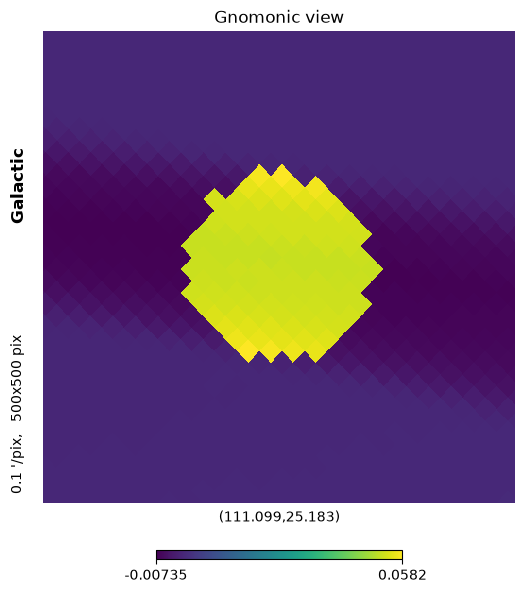

In [ ]:
run_path = [
    # "/shared_home/henachman/data/sim_outputs/filterbin_f090_i1_Mars",
    "/shared_home/henachman/data/sim_outputs/Marsskymap_f090_20261009",
]

maps_to_load = [
    f"{path}/filterbin_filtered_map.fits" for path in run_path
]

hit_maps = [
    f"{path}/filterbin_filtered_hits.fits" for path in run_path
]

ra = 111.0992
dec = 25.1832

N = 500 # Num pix
pix_size = 0.1 # arcmin per pix
patch_size = N*pix_size
for i, path in enumerate(maps_to_load):
    hpmap = hp.read_map(maps_to_load[i])
    hphits = hp.read_map(hit_maps[i])
    proj_map = hp.gnomview(hpmap, 
                rot=[ra, dec], 
                xsize=N,
                reso=pix_size,
                coord=["G"],
                return_projected_map=True,
                )
    half = int(patch_size/ pix_size // 2)
    cx   = N // 2


# Beam Profiles - From CMB Summer School 2026

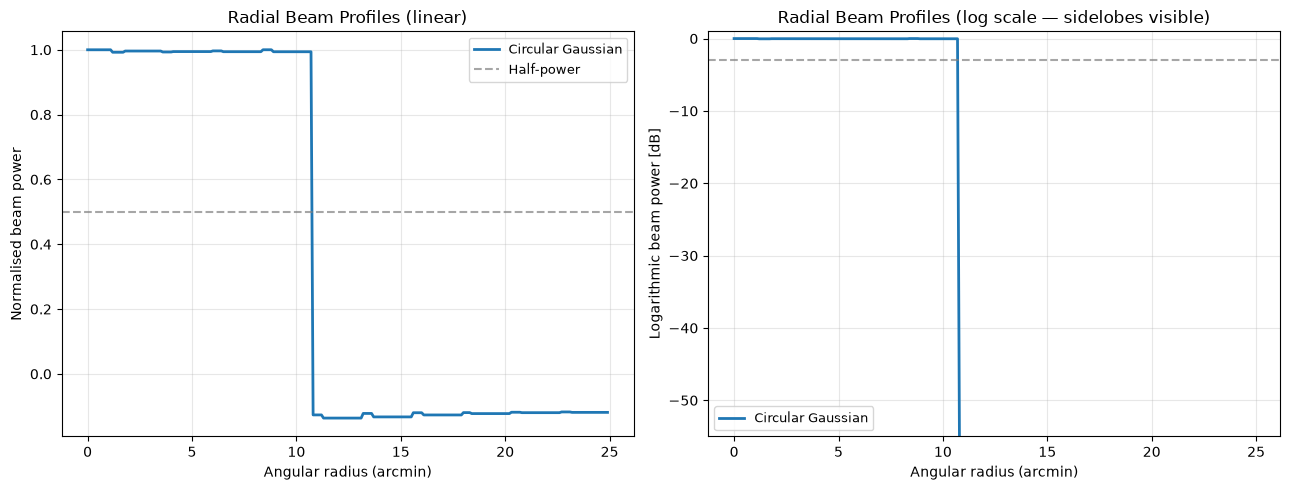


Key observation: The Airy beam has significant sidelobes (rings) that the Gaussian model misses entirely.
The elliptical beam differs between x- and y-cuts, breaking azimuthal symmetry.


In [ ]:
# Radial beam profiles
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

r_pix  = np.arange(0, half)
r_amin = r_pix * pix_size

# Take cuts through the centre pixel
def radial_cut(beam, cx):
    return beam[cx, cx:cx + half] / beam[cx, cx]

ax = axes[0]
ax.plot(r_amin, radial_cut(proj_map, cx), label='Circular Gaussian', lw=2)
ax.axhline(0.5, color='grey', ls='--', alpha=0.7, label='Half-power')
ax.set_xlabel('Angular radius (arcmin)')
ax.set_ylabel('Normalised beam power')
ax.set_title('Radial Beam Profiles (linear)')
ax.legend(fontsize=9)
# ax.set_xlim(0, 5*fwhm_nom)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(r_amin, 10*np.log10(np.maximum(radial_cut(proj_map, cx), 1e-6)), label='Circular Gaussian', lw=2)
ax.axhline(-3, color='grey', ls='--', alpha=0.7)
ax.set_xlabel('Angular radius (arcmin)')
ax.set_ylabel('Logarithmic beam power [dB]')
ax.set_title('Radial Beam Profiles (log scale — sidelobes visible)')
ax.legend(fontsize=9)
# ax.set_xlim(0, 5*fwhm_nom)
ax.set_ylim(-55, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Beam Profiles

In [12]:
# Function stolen from 
# https://github.com/simonsobs/mf-cmg-paper-beams/blob/main/abscal_pipeline/abscal_utils.py
def calc_rad_profile(map, binsize=0.5, normalize=True, positive_only=False):
    """Function to calculate the radial profile of an input beam map.
    Assumes that the beam center is at the center of the map. 

    Args:
        map (ndmap): 2D ndmap to profile
        binsize (float, optional): radial bin size
        normalize (bool, optional): Normalizes profile to center pixel
    Returns:
        rad_prof (dictionary): Keys of 'radius', 'profile', and 'bin_stdev'
    """
    rad_prof = {'radius':[], 'profile':[],'bin_stdev':[]}    
    rad = np.array([])
    amps = np.array([])
    stdevs = np.array([])

    # setup
    pos = map.posmap()
    ra = pos[1]
    dec= pos[0]    
    r = np.sqrt(ra**2 + dec**2) # radians
    r = r*u.rad.to(u.arcmin) # convert to arcmin
    r_max = np.nanmax(r)
    r_bins= np.arange(0, r_max, binsize)
    
    # take radial average
    if positive_only:
        for i in range(len(r_bins)-1):
            idx = (r > r_bins[i]) & (r < r_bins[i+1]) & (map >= 0)
            # idx = (r > r_bins[i]) & (r < r_bins[i+1])
            ravg = np.nanmean(map[idx])
            vars = np.nanstd(map[idx])
            
            rad = np.append(rad,(r_bins[i] + r_bins[i+1])/2)
            amps = np.append(amps,ravg)
            stdevs = np.append(stdevs, vars)
    else:
        for i in range(len(r_bins)-1):
            # idx = (r > r_bins[i]) & (r < r_bins[i+1]) & (map >= 0)
            idx = (r > r_bins[i]) & (r < r_bins[i+1])
            ravg = np.nanmean(map[idx])
            vars = np.nanstd(map[idx])
            
            rad = np.append(rad,(r_bins[i] + r_bins[i+1])/2)
            amps = np.append(amps,ravg)
            stdevs = np.append(stdevs, vars)
    
    
    #take peak for normalization as maximum pixel value within 2 arcmin of r=0, so as to avoid degeneracy with FWHM in fitting
    peakidx = r < 2
    peak = np.nanmean(map[peakidx])
    if normalize:
        amps /= peak
        amps= np.append(np.array([1]),amps)
        rad = np.append(np.array([0]), rad)
    
    rad_prof['radius'] = rad
    rad_prof['profile']   = amps
    rad_prof['bin_stdev']= stdevs

    return rad_prof

In [20]:
# 1. Load or define your HEALPix map (e.g., ring or nested ordering)
healmap = hp.read_map(maps_to_load[0])

# 2. Define the target enmap geometry (shape and WCS)
# Example: a full-sky CAR (plate-Carrée) projection
res = 1.5 * utils.arcmin  # resolution in radians
shape, wcs = enmap.fullsky_geometry(res=res, proj="car")

# Or for a custom submap / patch:
# box = np.array([[-5, 10], [5, -10]]) * utils.degree
# shape, wcs = enmap.geometry(pos=box, res=res, proj='car')

# 3. Reproject HEALPix to enmap
enmap_result = reproject.healpix2map(
    healmap, shape=shape, wcs=wcs, method="harm"
)  # 'harm' (spherical harmonics) or 'spline' / 'nearest'

rad_prof = calc_rad_profile(enmap_result, positive_only=True)


/tmp/ipykernel_1129944/204691385.py:33: RuntimeWarning: Mean of empty slice
  ravg = np.nanmean(map[idx])
/shared_home/software/soconda_builds/soconda_20260813_0.2.5/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1129944/204691385.py:33: RuntimeWarning: Mean of empty slice
  ravg = np.nanmean(map[idx])
/shared_home/software/soconda_builds/soconda_20260813_0.2.5/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


KeyboardInterrupt: 

In [ ]:

plt.plot(rad_prof['radius'], rad_prof['profile'])